# Tweet Sentiment Analysis — PPKM Indonesia
**Goal:** Klasifikasi sentimen tweet berbahasa Indonesia seputar kebijakan PPKM

**Dataset:** `INA_TweetsPPKM_Labeled_Pure.csv`
- 23.644 tweet berlabel sentimen
- Label: `0` = Positif, `1` = Netral, `2` = Negatif

**Pipeline:**
1. Import Library
2. Load Data & EDA
3. Text Preprocessing
4. Feature Extraction (TF-IDF)
5. Model Training (Logistic Regression, Naive Bayes, SVM, Random Forest)
6. Evaluasi Model
7. Model Comparison
8. Prediksi Teks Baru
9. Ringkasan

## 1. Import Library

In [ ]:
import re
import string
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)

warnings.filterwarnings('ignore')
print('Library siap!')

Library siap!


## 2. Load Data & EDA

In [8]:
# Load dataset
BASE_DIR = Path(r'D:\ML')
CSV_PATH = BASE_DIR / 'INA_TweetsPPKM_Labeled_Pure.csv'

df = pd.read_csv(CSV_PATH, sep='\t')

# Map label ke nama sentimen
LABEL_MAP = {0: 'Positif', 1: 'Netral', 2: 'Negatif'}
df['sentiment_label'] = df['sentiment'].map(LABEL_MAP)

print(f'Total tweet     : {len(df):,}')
print(f'Kolom           : {df.columns.tolist()}')
print(f'Periode data    : {df["Date"].min()} → {df["Date"].max()}')
df.head(10)

Total tweet     : 23,644
Kolom           : ['Date', 'User', 'Tweet', 'sentiment', 'sentiment_label']
Periode data    : 2020-05-06 04:34:13+00:00 → 2022-03-31 14:32:04+00:00


,Date,User,Tweet,sentiment,sentiment_label
0,2022-03-31 14:32:04+00:00,pikobar_jabar,Ketahui informasi pembagian #PPKM di wilayah J...,1,Netral
1,2022-03-31 09:26:00+00:00,inewsdotid,Tempat Ibadah di Wilayah PPKM Level 1 Boleh Be...,1,Netral
2,2022-03-31 05:02:34+00:00,vdvc_talk,"Juru bicara Satgas Covid-19, Wiku Adisasmito m...",1,Netral
3,2022-03-30 14:23:10+00:00,pikobar_jabar,Ketahui informasi pembagian #PPKM di wilayah J...,1,Netral
4,2022-03-30 11:28:57+00:00,tvOneNews,Kementerian Agama menerbitkan Surat Edaran Nom...,1,Netral
5,2022-03-30 11:21:18+00:00,lampungpost_,"Kapasitas tempat ibadah, termasuk masjid, yang...",1,Netral
6,2022-03-30 08:00:19+00:00,akusehatklinik,"Halo Sobat Sehat\n\nDengan adanya kondisi ini,...",1,Netral
7,2022-03-30 04:35:57+00:00,matamilenialID,Mitigasi Penting untuk Cegah Penyebaran Varian...,1,Netral
8,2022-03-30 04:21:08+00:00,lampungpostid,Sebanyak 5 (lima) kabupaten di Provinsi Lampun...,1,Netral
9,2022-03-30 03:16:52+00:00,gemaposID,Komentar Satgas Penanganan Covid-19 Tentang Bu...,1,Netral


In [9]:
print('=== Info Dataset ===')
print(df.dtypes)
print(f'\nMissing values:')
print(df.isnull().sum())
print(f'\nDistribusi Sentimen:')
print(df['sentiment_label'].value_counts())

=== Info Dataset ===
Date                 str
User                 str
Tweet                str
sentiment          int64
sentiment_label      str
dtype: object

Missing values:
Date               0
User               0
Tweet              0
sentiment          0
sentiment_label    0
dtype: int64

Distribusi Sentimen:
sentiment_label
Netral     17706
Negatif     3980
Positif     1958
Name: count, dtype: int64


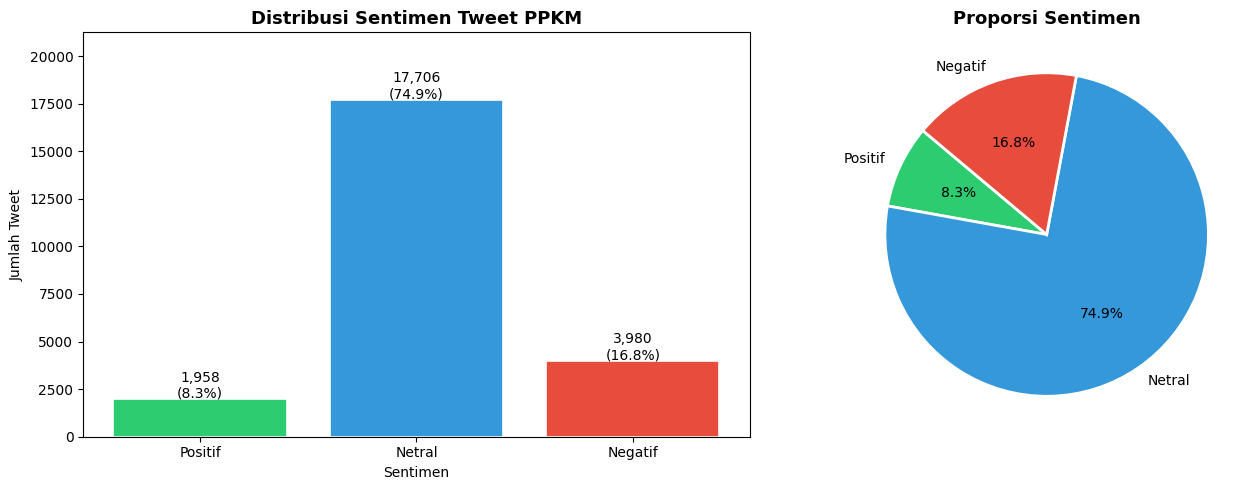

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart distribusi sentimen
counts = df['sentiment_label'].value_counts().reindex(['Positif', 'Netral', 'Negatif'])
colors = ['#2ecc71', '#3498db', '#e74c3c']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('Distribusi Sentimen Tweet PPKM', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Sentimen')
axes[0].set_ylabel('Jumlah Tweet')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=10)
axes[0].set_ylim(0, counts.max() * 1.2)

# Pie chart
axes[1].pie(counts.values, labels=counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Proporsi Sentimen', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

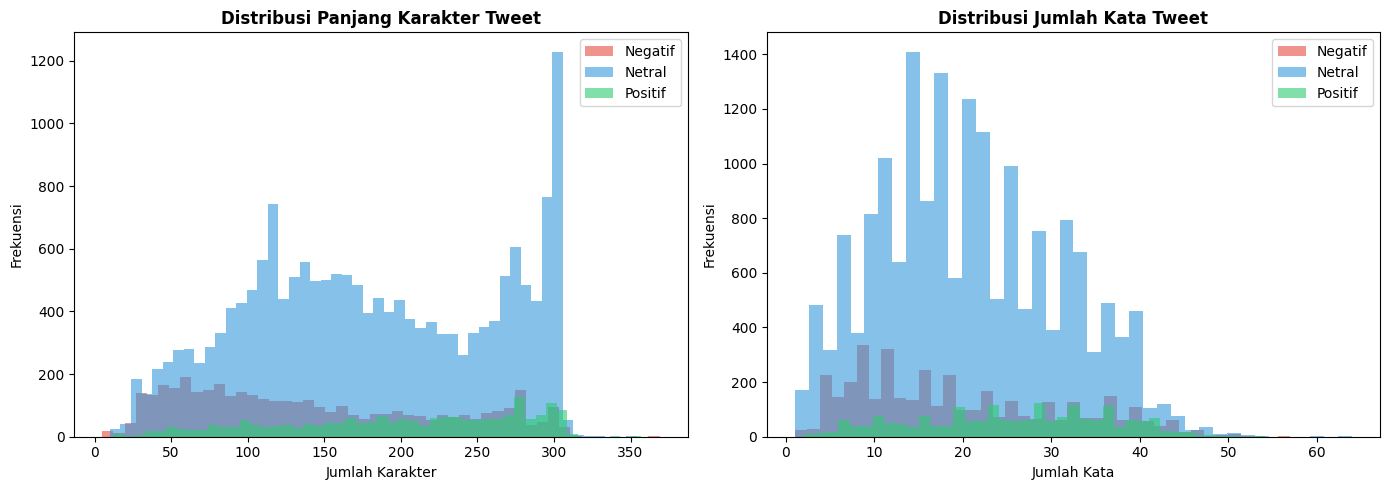

                 tweet_len  word_count
sentiment_label                       
Negatif              140.8        19.6
Netral               181.2        20.7
Positif              199.5        25.4


In [11]:
# Distribusi panjang tweet per sentimen
df['tweet_len'] = df['Tweet'].astype(str).apply(len)
df['word_count'] = df['Tweet'].astype(str).apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = {'Positif': '#2ecc71', 'Netral': '#3498db', 'Negatif': '#e74c3c'}

for label, grp in df.groupby('sentiment_label'):
    axes[0].hist(grp['tweet_len'], bins=50, alpha=0.6,
                 label=label, color=palette[label])
axes[0].set_title('Distribusi Panjang Karakter Tweet', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Jumlah Karakter')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

for label, grp in df.groupby('sentiment_label'):
    axes[1].hist(grp['word_count'], bins=40, alpha=0.6,
                 label=label, color=palette[label])
axes[1].set_title('Distribusi Jumlah Kata Tweet', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Jumlah Kata')
axes[1].set_ylabel('Frekuensi')
axes[1].legend()

plt.tight_layout()
plt.show()

print(df.groupby('sentiment_label')[['tweet_len', 'word_count']].mean().round(1))

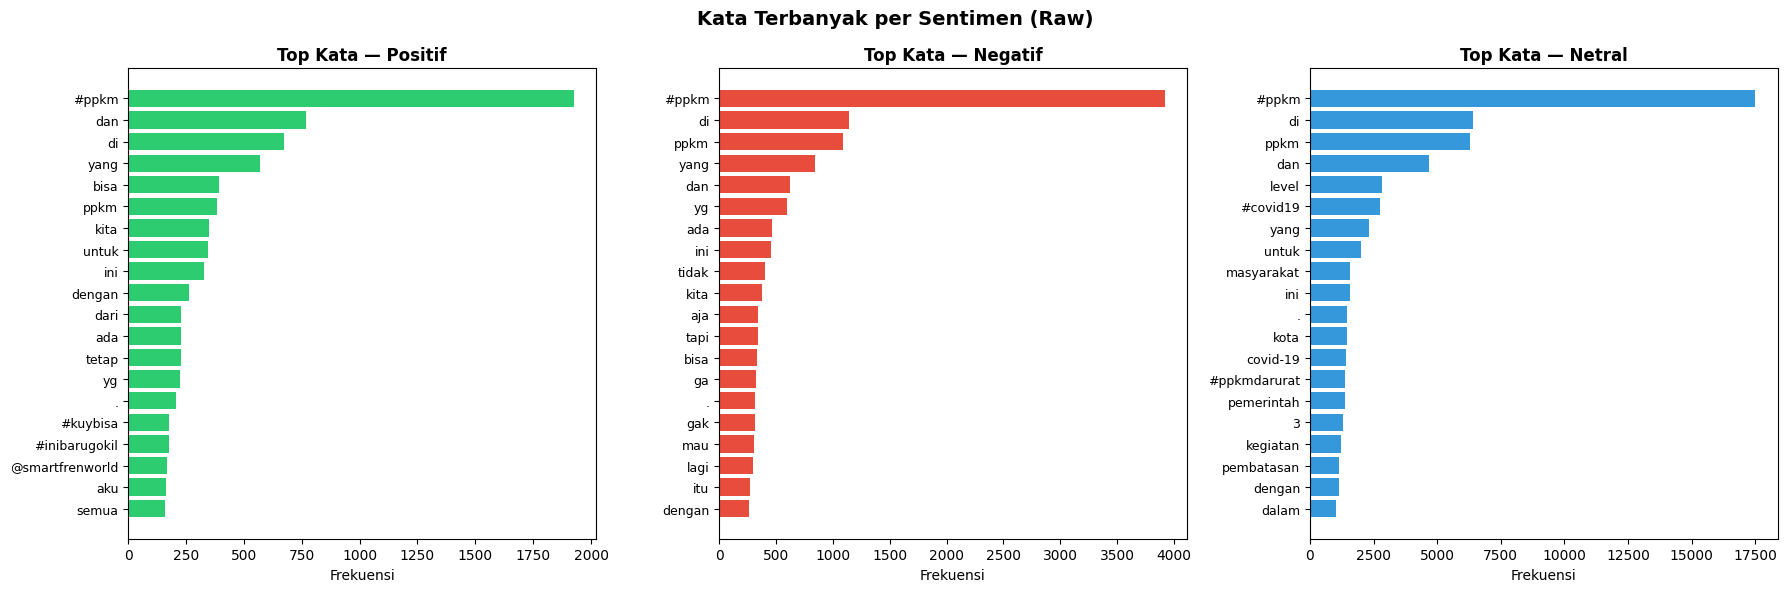

In [12]:
# Top 20 kata per sentimen (sebelum cleaning)
def top_words(series, n=20):
    all_words = ' '.join(series.astype(str)).lower().split()
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiments = ['Positif', 'Negatif', 'Netral']
colors_map = {'Positif': '#2ecc71', 'Negatif': '#e74c3c', 'Netral': '#3498db'}

for ax, s in zip(axes, sentiments):
    words = top_words(df[df['sentiment_label'] == s]['Tweet'])
    words_df = pd.DataFrame(words, columns=['word', 'count'])
    ax.barh(words_df['word'][::-1], words_df['count'][::-1], color=colors_map[s])
    ax.set_title(f'Top Kata — {s}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Frekuensi')
    ax.tick_params(axis='y', labelsize=9)

plt.suptitle('Kata Terbanyak per Sentimen (Raw)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

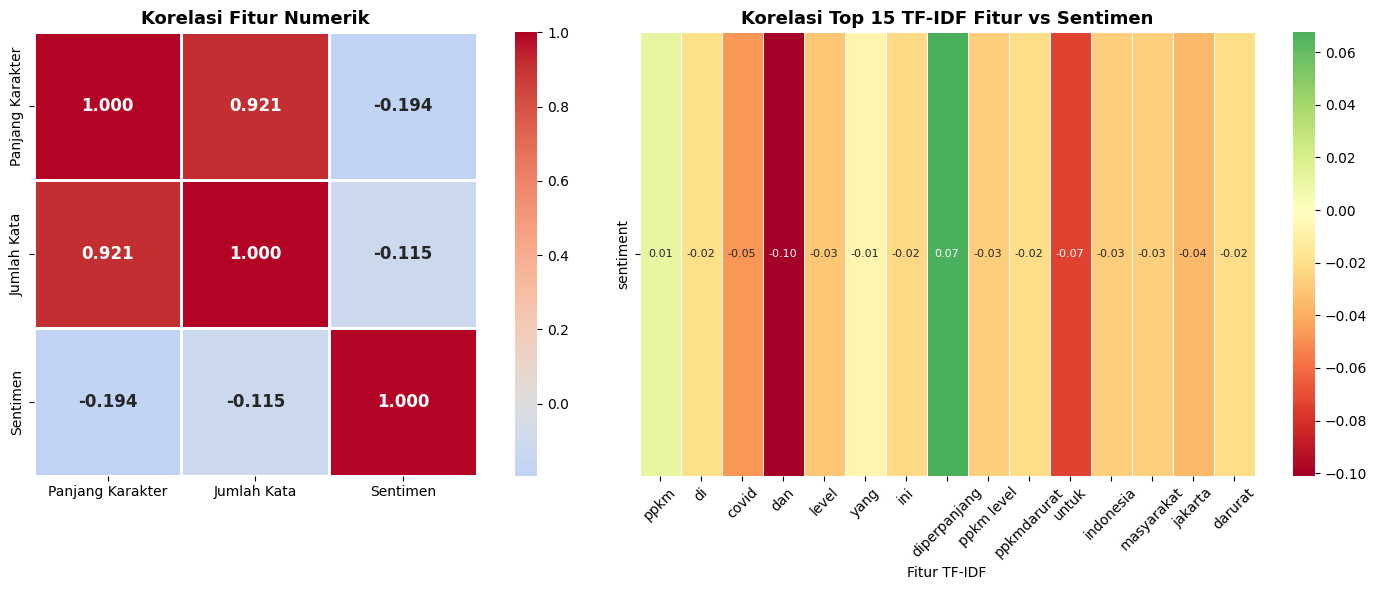

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Heatmap 1: Korelasi fitur numerik vs sentimen ---
num_features = df[['tweet_len', 'word_count', 'sentiment']].copy()
num_features.columns = ['Panjang Karakter', 'Jumlah Kata', 'Sentimen']
corr1 = num_features.corr()

sns.heatmap(corr1, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            ax=axes[0], linewidths=1, square=True,
            annot_kws={'size': 12, 'weight': 'bold'})
axes[0].set_title('Korelasi Fitur Numerik', fontsize=13, fontweight='bold')

# --- Heatmap 2: Korelasi top 15 TF-IDF fitur vs sentimen ---
TOP_N = 15
top_feat_idx = tfidf_sum.argsort()[-TOP_N:][::-1]
top_feat_names = [feature_names[i] for i in top_feat_idx]

# Ambil nilai TF-IDF fitur tersebut dari training set
tfidf_dense = pd.DataFrame(
    X_train_tfidf[:, top_feat_idx].toarray(),
    columns=top_feat_names
)
tfidf_dense['sentiment'] = y_train.values
corr2 = tfidf_dense.corr()[['sentiment']].drop('sentiment').T

sns.heatmap(corr2, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[1], linewidths=0.5,
            annot_kws={'size': 8})
axes[1].set_title(f'Korelasi Top {TOP_N} TF-IDF Fitur vs Sentimen', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Fitur TF-IDF')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [15]:
def clean_tweet(text):
    """Bersihkan teks tweet dari noise."""
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)          # hapus URL
    text = re.sub(r'@\w+', '', text)                     # hapus mention
    text = re.sub(r'#(\w+)', r'\1', text)                # hapus simbol hashtag
    text = re.sub(r'[^\w\s]', ' ', text)                 # hapus tanda baca
    text = re.sub(r'\d+', '', text)                      # hapus angka
    text = re.sub(r'\s+', ' ', text).strip()             # normalisasi spasi
    return text

# Terapkan cleaning
df['tweet_clean'] = df['Tweet'].apply(clean_tweet)

print('Contoh hasil cleaning:')
for _, row in df.sample(5, random_state=42).iterrows():
    print(f'  ASLI  : {row["Tweet"][:80]}')
    print(f'  BERSIH: {row["tweet_clean"][:80]}')
    print()

Contoh hasil cleaning:
  ASLI  : Datangi Pemilik Warung, Bripka Iwan Handayana Himbau Prokes dan PPKM  https://t.
  BERSIH: datangi pemilik warung bripka iwan handayana himbau prokes dan ppkm ppkm covid k

  ASLI  : PPKM Tahap Dua, PKL Diberikan kelonggaran berjualan hingga pukul 20.00 WIB. #War
  BERSIH: ppkm tahap dua pkl diberikan kelonggaran berjualan hingga pukul wib wartajateng 

  ASLI  : #PPKM nambah lv nambah harga ga sih
  BERSIH: ppkm nambah lv nambah harga ga sih

  ASLI  : Terjadi Tren perbaikan pada kasus COVID-19, untuk itu presiden @jokowi melanjutk
  BERSIH: terjadi tren perbaikan pada kasus covid untuk itu presiden melanjutkan ppkm hing

  ASLI  : Setiap orang itu baik hanya saja dia belum tentu tahu bagaimana menjadi baik ses
  BERSIH: setiap orang itu baik hanya saja dia belum tentu tahu bagaimana menjadi baik ses



In [16]:
# Train / Validation / Test split (70 / 15 / 15)
X = df['tweet_clean']
y = df['sentiment']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)

print(f'Train : {len(X_train):,}')
print(f'Val   : {len(X_val):,}')
print(f'Test  : {len(X_test):,}')

Train : 16,550
Val   : 3,547
Test  : 3,547


In [17]:
## 4. Feature Extraction (TF-IDF)
# TF-IDF dengan unigram + bigram
tfidf = TfidfVectorizer(
    max_features=30_000,
    ngram_range=(1, 2),
    min_df=3,
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'Vocabulary size : {len(tfidf.vocabulary_):,}')
print(f'Train matrix    : {X_train_tfidf.shape}')
print(f'Val matrix      : {X_val_tfidf.shape}')
print(f'Test matrix     : {X_test_tfidf.shape}')

Vocabulary size : 23,488
Train matrix    : (16550, 23488)
Val matrix      : (3547, 23488)
Test matrix     : (3547, 23488)


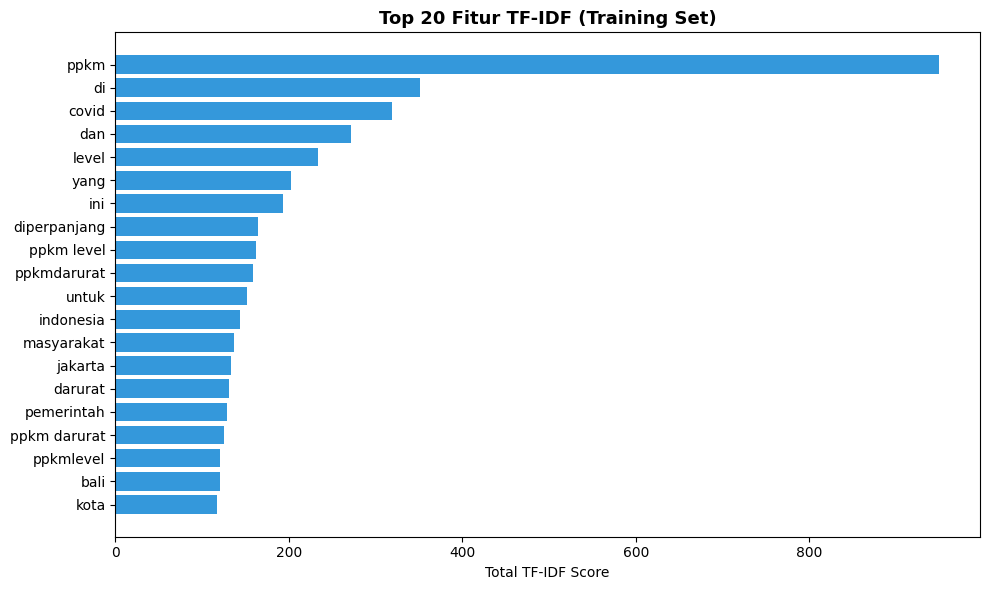

In [18]:
# Top fitur TF-IDF global
feature_names = tfidf.get_feature_names_out()
tfidf_sum = np.asarray(X_train_tfidf.sum(axis=0)).flatten()
top_idx = tfidf_sum.argsort()[-20:][::-1]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh([feature_names[i] for i in top_idx[::-1]],
        tfidf_sum[top_idx[::-1]], color='#3498db')
ax.set_title('Top 20 Fitur TF-IDF (Training Set)', fontsize=13, fontweight='bold')
ax.set_xlabel('Total TF-IDF Score')
plt.tight_layout()
plt.show()

## 5. Model Training

In [20]:
CLASSIFIERS = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Naive Bayes'        : MultinomialNB(alpha=0.1),
    'Linear SVM'         : LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42),
}

results = {}
for name, clf in CLASSIFIERS.items():
    clf.fit(X_train_tfidf, y_train)
    val_pred = clf.predict(X_val_tfidf)
    acc = accuracy_score(y_val, val_pred)
    f1  = f1_score(y_val, val_pred, average='macro')
    results[name] = {'model': clf, 'val_acc': acc, 'val_f1': f1}
    print(f'{name:<22} | Val Acc: {acc*100:.2f}%  | Val F1 (macro): {f1:.4f}')

# Pilih model terbaik berdasarkan F1 macro
best_name = max(results, key=lambda k: results[k]['val_f1'])
best_model = results[best_name]['model']
print(f'\n→ Model terbaik (val): {best_name}')

Logistic Regression    | Val Acc: 86.10%  | Val F1 (macro): 0.6933
Naive Bayes            | Val Acc: 83.99%  | Val F1 (macro): 0.7114
Linear SVM             | Val Acc: 86.72%  | Val F1 (macro): 0.7313
Random Forest          | Val Acc: 83.51%  | Val F1 (macro): 0.6291

→ Model terbaik (val): Linear SVM


## 6. Evaluasi Model Terbaik

In [21]:
# Evaluasi pada test set
y_pred = best_model.predict(X_test_tfidf)
test_acc = accuracy_score(y_test, y_pred)
test_f1  = f1_score(y_test, y_pred, average='macro')

print(f'=== {best_name} — Test Set ===')
print(f'Accuracy : {test_acc*100:.2f}%')
print(f'F1 Macro : {test_f1:.4f}')
print()
TARGET_NAMES = ['Positif', 'Netral', 'Negatif']
print(classification_report(y_test, y_pred, target_names=TARGET_NAMES))

=== Linear SVM — Test Set ===
Accuracy : 86.44%
F1 Macro : 0.7400

              precision    recall  f1-score   support

     Positif       0.70      0.50      0.58       294
      Netral       0.91      0.94      0.92      2656
     Negatif       0.73      0.70      0.71       597

    accuracy                           0.86      3547
   macro avg       0.78      0.71      0.74      3547
weighted avg       0.86      0.86      0.86      3547

